
**Statistical Hypothesis Testing: Customer Sales Across Operating Regions**

**Objective**

The objective of this analysis is to determine whether customer-level sales differ across the company's operating regions. Because some customers purchased from multiple regions, the analysis uses within-customer comparisons to account for the dependence between regional observations.

Two analyses are conducted:

A paired comparison of East and West sales among customers who purchased in both regions.
A repeated-measures comparison of Central, East, South, and West sales among customers who purchased in all four regions.

A significance level of (alpha=0.05) is used throughout the hypothesis-testing procedures.

**Analytical Approach**

The analysis combines parametric and non-parametric methods to assess the robustness of the findings.

For the East-West comparison, the analysis uses:

Paired-samples t-test
Cohen's d effect size
Wilcoxon signed-rank test
Sign-flip permutation test

For the four-region comparison, the analysis uses:

Normality assessment
Log transformation
Mauchly's test of sphericity
Greenhouse-Geisser correction
Repeated-measures ANOVA
Holm-adjusted post-hoc comparisons
Within-customer permutation test

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**Data Loading and Preparation**

In [2]:
retail = pd.read_csv(r"C:\ProgramData\MySQL\MySQL Server 8.0\Uploads\Superstore dataset combined.csv")
retail.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,7,CA-2014-115812,9-Jun-14,14-Jun-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.28,4,0.0,1.9656
1,10,CA-2014-115812,9-Jun-14,14-Jun-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-AP-10002892,Office Supplies,Appliances,Belkin F5C206VTEL 6 Outlet Surge,114.90,5,0.0,34.4700
2,172,CA-2014-118962,5-Aug-14,9-Aug-14,Standard Class,CS-12130,Chad Sievert,Consumer,United States,Los Angeles,...,90004,West,OFF-PA-10000659,Office Supplies,Paper,"Adams Phone Message Book, Professional, 400 Me...",20.94,3,0.0,9.8418
3,173,CA-2014-118962,5-Aug-14,9-Aug-14,Standard Class,CS-12130,Chad Sievert,Consumer,United States,Los Angeles,...,90004,West,OFF-PA-10001144,Office Supplies,Paper,Xerox 1913,110.96,2,0.0,53.2608
4,1143,CA-2014-146969,29-Sep-14,3-Oct-14,Standard Class,AP-10915,Arthur Prichep,Consumer,United States,Los Angeles,...,90045,West,OFF-FA-10001561,Office Supplies,Fasteners,Stockwell Push Pins,8.72,4,0.0,2.8776


In [3]:
retail.isna().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [4]:
retail.duplicated().sum()

np.int64(0)

In [5]:
retail[retail['Sales']<0]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit


In [6]:
customer_region= retail.groupby(['Customer ID','Region'])['Sales'].sum().reset_index()
customer_region

,Customer ID,Region,Sales
0,AA-10315,Central,4780.552
1,AA-10315,East,29.500
2,AA-10315,West,753.508
3,AA-10375,Central,178.370
4,AA-10375,East,206.732
...,...,...,...
2496,ZC-21910,South,1470.892
2497,ZC-21910,West,2641.089
2498,ZD-21925,Central,331.080
2499,ZD-21925,South,856.664


In [7]:
customer_region.groupby('Customer ID')['Region'].nunique().value_counts()

Region
3    340
4    301
2    125
1     27
Name: count, dtype: int64

In [8]:
customer_specific_regions= customer_region.groupby('Customer ID')['Region'].agg(set)
customer_specific_regions

Customer ID
AA-10315           {West, East, Central}
AA-10375    {West, East, Central, South}
AA-10480          {East, Central, South}
AA-10645    {West, East, Central, South}
AB-10015                 {West, Central}
                        ...             
XP-21865    {West, East, Central, South}
YC-21895           {West, East, Central}
YS-21880             {West, East, South}
ZC-21910    {West, East, Central, South}
ZD-21925          {West, South, Central}
Name: Region, Length: 793, dtype: object

In [9]:
central_west_customers= (customer_specific_regions[customer_specific_regions=={'Central','West'}])
central_west_customers

Customer ID
AB-10015    {West, Central}
BF-11005    {West, Central}
BT-11305    {West, Central}
CC-12145    {West, Central}
CC-12550    {West, Central}
CM-11815    {West, Central}
CM-12445    {West, Central}
CS-11845    {West, Central}
CS-12130    {West, Central}
EK-13795    {West, Central}
GT-14755    {West, Central}
JD-16060    {West, Central}
JF-15295    {West, Central}
MC-17635    {West, Central}
ML-18040    {West, Central}
MT-18070    {West, Central}
RD-19930    {West, Central}
RP-19270    {West, Central}
RR-19315    {West, Central}
RW-19540    {West, Central}
SC-20845    {West, Central}
SG-20080    {West, Central}
SS-20590    {West, Central}
TP-21565    {West, Central}
VF-21715    {West, Central}
Name: Region, dtype: object

In [10]:
central_east_customers= (customer_specific_regions[customer_specific_regions=={'Central','East'}])
central_east_customers
len(central_east_customers)

27

In [12]:
west_south_customers= (customer_specific_regions[customer_specific_regions.apply(lambda x: len(x)==2 and {'West','South'}.issubset(x))])
west_south_customers
print(len(west_south_customers))

23


In [13]:
west_east_customers= (customer_specific_regions[customer_specific_regions.apply(lambda x: x=={'West','East'})])
west_east_customers
print(len(west_east_customers))

32


## Running a paired t-test
#### We are picking customers that operate both in the east and west region
#### you can pick any pair of your choice

**East vs West paired analysis**

In [14]:
west_east= west_east_customers.index

In [15]:
west_east_sample = customer_region[customer_region['Customer ID'].isin(west_east)]
west_east_sample.reset_index(drop= True)

,Customer ID,Region,Sales
0,AG-10300,East,81.940
1,AG-10300,West,285.608
2,AJ-10960,East,618.608
3,AJ-10960,West,10.640
4,AS-10135,East,54.640
...,...,...,...
59,PK-18910,West,18.900
60,SC-20440,East,562.544
61,SC-20440,West,1312.454
62,SW-20755,East,663.964


In [16]:
west_east_sample= west_east_sample.set_index(['Customer ID','Region'])['Sales']

In [17]:
west_east_sample= west_east_sample.unstack()
west_east_sample

Region,East,West
Customer ID,,
AG-10300,81.940,285.608
AJ-10960,618.608,10.640
AS-10135,54.640,4.180
AY-10555,8.016,488.998
BS-11800,760.800,188.630
BT-11530,381.952,2302.540
CD-12280,796.036,409.548
CM-12115,800.040,861.570
DB-13360,863.842,217.624


### Hypothesis
##### Question: For customers operating both in our east and west region, is their mean sales different

###### null hypothesis H0: difference = 0
###### Alternate hypothesis H1: difference != 0
###### Alpha: 0.05

In [18]:
west_east_sample['difference']= west_east_sample['East']-west_east_sample['West']

In [19]:
west_east_sample

Region,East,West,difference
Customer ID,,,
AG-10300,81.940,285.608,-203.668
AJ-10960,618.608,10.640,607.968
AS-10135,54.640,4.180,50.460
AY-10555,8.016,488.998,-480.982
BS-11800,760.800,188.630,572.170
BT-11530,381.952,2302.540,-1920.588
CD-12280,796.036,409.548,386.488
CM-12115,800.040,861.570,-61.530
DB-13360,863.842,217.624,646.218


**Assumption checks**

In [20]:
west_east_sample['difference'].describe()

count      32.000000
mean      -25.925562
std      1318.630810
min     -3773.906000
25%      -697.615500
50%        47.811500
75%       687.361750
max      2716.462000
Name: difference, dtype: float64

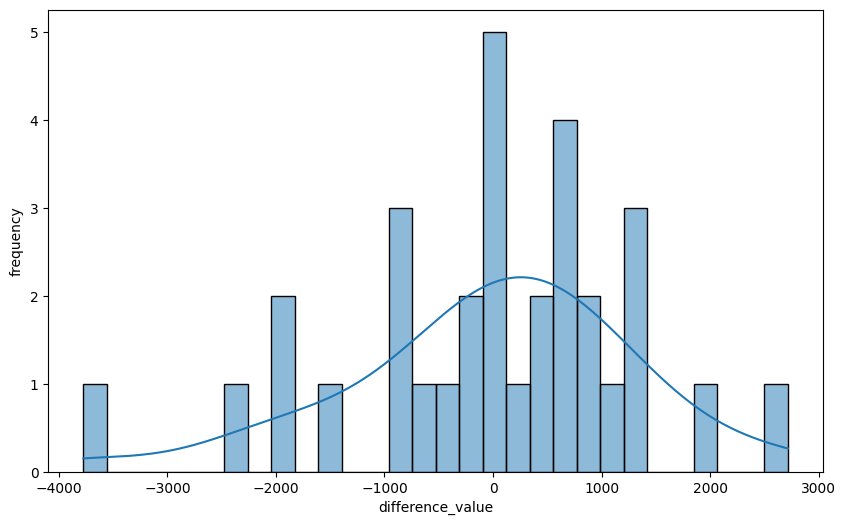

In [21]:
plt.figure(figsize=(10,6))
sns.histplot(data= west_east_sample,x=west_east_sample['difference'],bins=30,kde=True)
plt.xlabel('difference_value')
plt.ylabel('frequency')
plt.show()

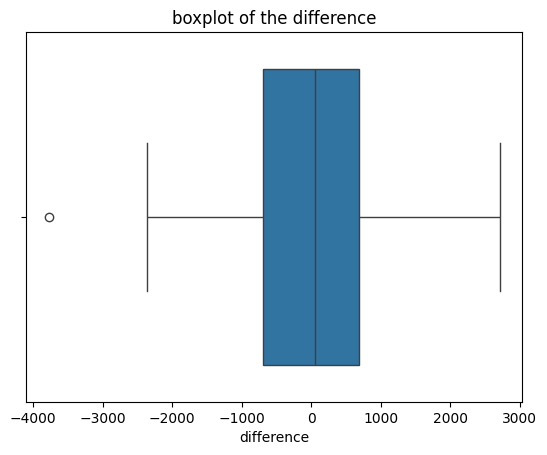

In [22]:
sns.boxplot(data= west_east_sample,x=west_east_sample['difference'])
plt.xlabel('difference')
plt.title('boxplot of the difference')
plt.show()

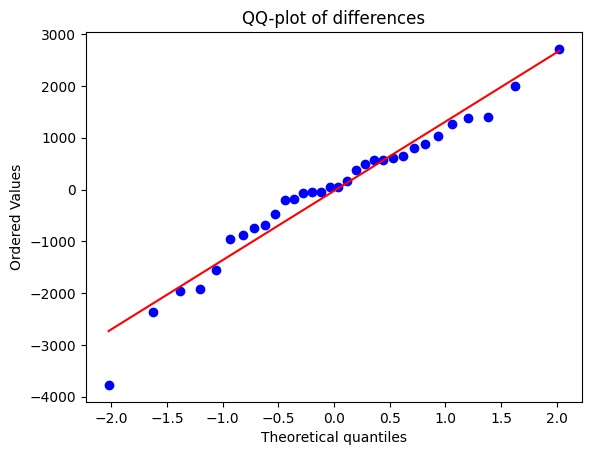

In [23]:
import scipy.stats as stats
stats.probplot(west_east_sample['difference'],dist='norm',plot=plt)
plt.title('QQ-plot of differences')
plt.show()

**Paired t-test**

In [24]:
from scipy.stats import ttest_rel
result= ttest_rel(west_east_sample['East'],west_east_sample['West'])
print('t_statistics:', result.statistic)
print('p_value:', result.pvalue)
print('p_value:', result.confidence_interval())

t_statistics: -0.11121924898985504
p_value: 0.9121594764341735
p_value: ConfidenceInterval(low=np.float64(-501.34266704242884), high=np.float64(449.49154204242905))


#### Effect size: Cohen's d

In [25]:
d_mean = west_east_sample['difference'].mean()
d_std = west_east_sample['difference'].std(ddof=1)
cohens_d= d_mean/d_std
cohens_d

np.float64(-0.019660971289800395)

#### Manual calculation of the confidence interval

In [153]:
# n= len(west_east_sample['difference'])
# se= d_std/(np.sqrt(n))
# t_critical = stats.t.ppf(0.975,df=n-1)
# lower= d_mean - t_critical*se
# upper = d_mean + t_critical*se
# print('95% CI:',(lower,upper))

95% CI: (np.float64(-501.34266704242884), np.float64(449.49154204242893))


## Robustness Check using Wilcoxon signed_rank test and Permutation method

### Wilcoxon Signed-Rank Test

In [26]:
from scipy.stats import wilcoxon
result= wilcoxon(west_east_sample['East'],west_east_sample['West'])
print(result)

WilcoxonResult(statistic=np.float64(252.0), pvalue=np.float64(0.8320396803319454))


### Permutation Test

In [27]:
differences = west_east_sample['difference'].to_numpy()
observed_difference = differences.mean()
rng = np.random.default_rng(42)
permutated_mean = []
for _ in range(10_000):
    signs= rng.choice([-1,1],size=len(differences))
    permutated_differences= np.mean(differences*signs)
    permutated_mean.append(permutated_differences)
permutated_mean = np.array(permutated_mean)

In [28]:
permutated_mean

array([  -2.8258125,  225.8376875, -112.494625 , ...,  281.2805625,
        -16.7170625,   34.5859375], shape=(10000,))

In [29]:
p_value = np.mean(np.abs(permutated_mean)>=np.abs(observed_difference))
p_value

np.float64(0.9123)

**Results**

East-West comparison

A paired-samples analysis was conducted among 32 customers who purchased from both the East and West regions. The mean difference in sales, calculated as East minus West, was −25.93 (SD = 1,318.63). A paired-samples t-test indicated that the difference was not statistically significant, t(31) = −0.111, p = 0.912. The 95% confidence interval for the mean difference ranged from −501.34 to 449.49 and included zero. The standardized effect size was very small (Cohen's d = −0.0196).

As robustness checks, the Wilcoxon signed-rank test also indicated no statistically significant difference (p = 0.832), while the sign-flip permutation test produced p = 0.9123. Thus, all three approaches led to the same conclusion at the 5% significance level: there was insufficient evidence to conclude that sales differed between the East and West regions among these customers.

## Repeated Measures ANOVA

**Four Region Analysis**

**Sample Preparation**

In [55]:
all_region = (customer_specific_regions[customer_specific_regions.apply(lambda x: len(x)==4 and {'Central','East','South','West'}.issubset(x))])

In [32]:
all_region

Customer ID
AA-10375    {West, East, Central, South}
AA-10645    {West, East, Central, South}
AB-10060    {West, East, Central, South}
AB-10105    {West, East, Central, South}
AB-10165    {West, East, Central, South}
                        ...             
VM-21835    {West, East, Central, South}
VP-21760    {West, East, Central, South}
VW-21775    {West, East, Central, South}
XP-21865    {West, East, Central, South}
ZC-21910    {West, East, Central, South}
Name: Region, Length: 301, dtype: object

In [33]:
all_region_customers= all_region.index

In [34]:
all_4_region = (customer_region[customer_region['Customer ID'].isin(all_region_customers)]).reset_index(drop=True)
all_4_region= all_4_region.rename(columns={'Customer ID':'Customer_ID'})
all_4_region

,Customer_ID,Region,Sales
0,AA-10375,Central,178.370
1,AA-10375,East,206.732
2,AA-10375,South,598.480
3,AA-10375,West,72.808
4,AA-10645,Central,1971.460
...,...,...,...
1199,XP-21865,West,660.190
1200,ZC-21910,Central,3869.806
1201,ZC-21910,East,43.920
1202,ZC-21910,South,1470.892


In [35]:
all_4_region.groupby('Customer_ID')['Region'].nunique().value_counts()

Region
4    301
Name: count, dtype: int64

In [36]:
all_4_region['Customer_ID'].nunique()

301

In [37]:
all_4_region.groupby(['Customer_ID','Region']).nunique().value_counts()

Sales
1        1204
Name: count, dtype: int64

## Hypothesis
### Question: For customers operating in all the regions, is their mean sales the same across all regions
##### null hypothesis H0: There is no difference across all four regions
##### Alternate hypothesis H1: There is at least a difference across our regions

**Raw Sales EDA and Assumptions Checking**

In [38]:
all_4_region.groupby('Region')['Sales'].describe()

,count,mean,std,min,25%,50%,75%,max
Region,,,,,,,,
Central,301.0,831.813205,1578.694120,0.556,111.650,408.422,999.980,18437.138
East,301.0,1086.165990,1527.422187,3.304,162.700,537.616,1408.346,10022.293
South,301.0,774.870779,1676.672330,1.167,87.940,307.820,863.928,23669.196
West,301.0,1002.307385,1349.448838,2.224,199.386,593.636,1312.344,14345.276


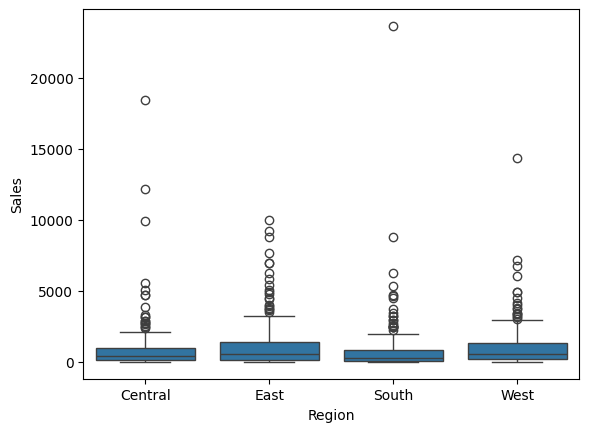

In [39]:
sns.boxplot(x='Region',y='Sales',data=all_4_region)
plt.show()

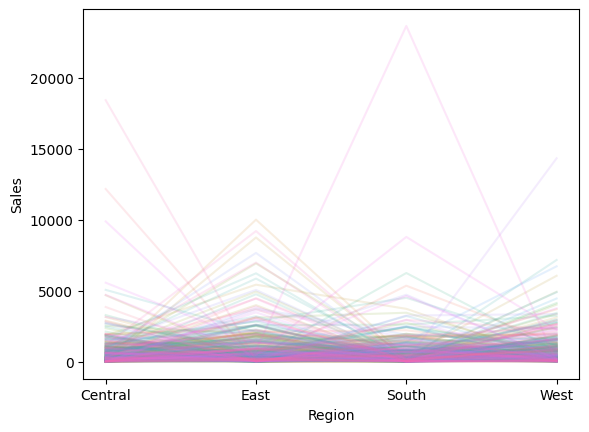

In [40]:
sns.lineplot(data=all_4_region,x='Region',y='Sales',hue='Customer_ID',legend=False, estimator=None,alpha=0.15)
plt.show()

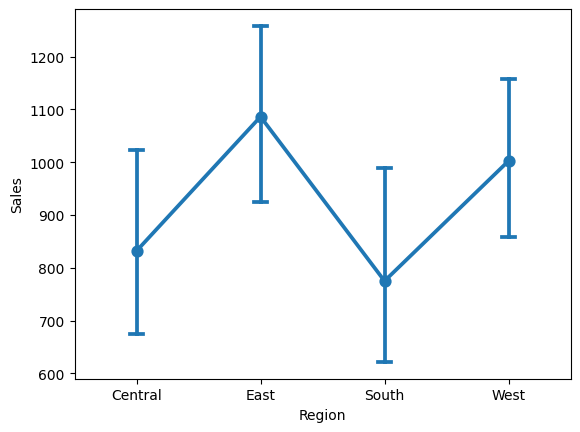

In [41]:
sns.pointplot(
    data=all_4_region,
    x='Region',
    y='Sales',
    errorbar='ci',
    capsize=0.1
)

plt.show()

In [42]:
import pingouin as pg

In [43]:
diagnostic_table = all_4_region.pivot(index='Customer_ID',columns='Region',values='Sales')
diagnostic_table

Region,Central,East,South,West
Customer_ID,,,,
AA-10375,178.370,206.732,598.480,72.808
AA-10645,1971.460,1434.330,291.740,1389.405
AB-10060,240.150,4487.352,334.200,2693.918
AB-10105,12181.594,117.960,843.840,1330.177
AB-10165,37.296,118.320,163.960,794.262
...,...,...,...,...
VM-21835,16.280,177.340,58.400,128.670
VP-21760,634.124,732.256,1893.786,100.360
VW-21775,1222.470,3725.512,21.360,1164.696


In [44]:
differences = pd.DataFrame({
     "Central-East": diagnostic_table["Central"] - diagnostic_table["East"],
    "Central-South": diagnostic_table["Central"] - diagnostic_table["South"],
    "Central-West": diagnostic_table["Central"] - diagnostic_table["West"],
    "East-South": diagnostic_table["East"] - diagnostic_table["South"],
    "East-West": diagnostic_table["East"] - diagnostic_table["West"],
    "South-West": diagnostic_table["South"] - diagnostic_table["West"]
})

In [45]:
differences.head()

,Central-East,Central-South,Central-West,East-South,East-West,South-West
Customer_ID,,,,,,
AA-10375,-28.362,-420.110,105.562,-391.748,133.924,525.672
AA-10645,537.130,1679.720,582.055,1142.590,44.925,-1097.665
AB-10060,-4247.202,-94.050,-2453.768,4153.152,1793.434,-2359.718
AB-10105,12063.634,11337.754,10851.417,-725.880,-1212.217,-486.337
AB-10165,-81.024,-126.664,-756.966,-45.640,-675.942,-630.302


#### Assumptions Checking

**Normality Check**

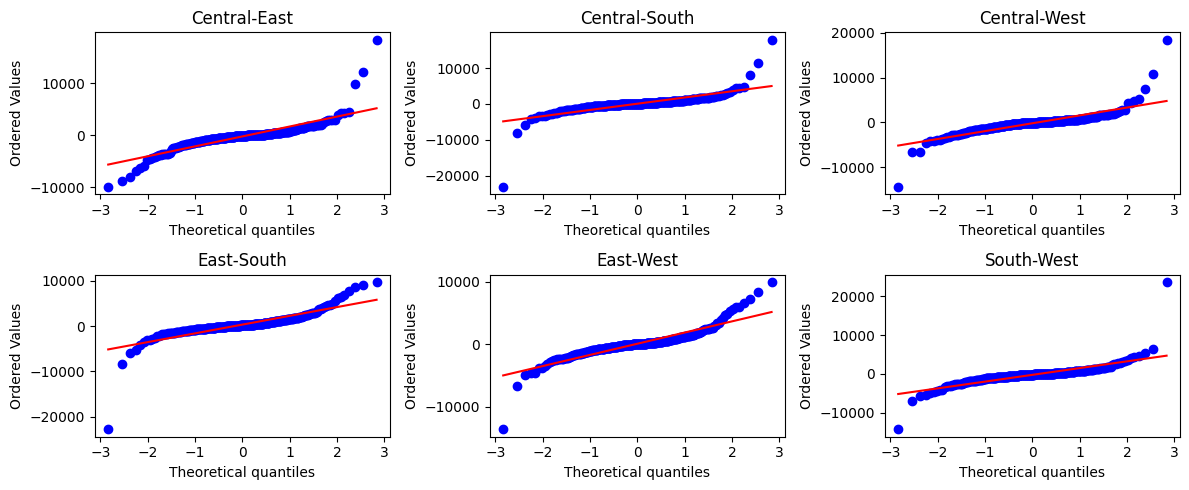

In [46]:
from scipy import stats
fig, axes= plt.subplots(
                    2,3,
                    figsize= (12,5))
for ax, column in zip(axes.flatten(),differences.columns):
    stats.probplot(differences[column],
                   dist='norm',
                   plot=ax)
    ax.set_title(column)
plt.tight_layout()
plt.show()


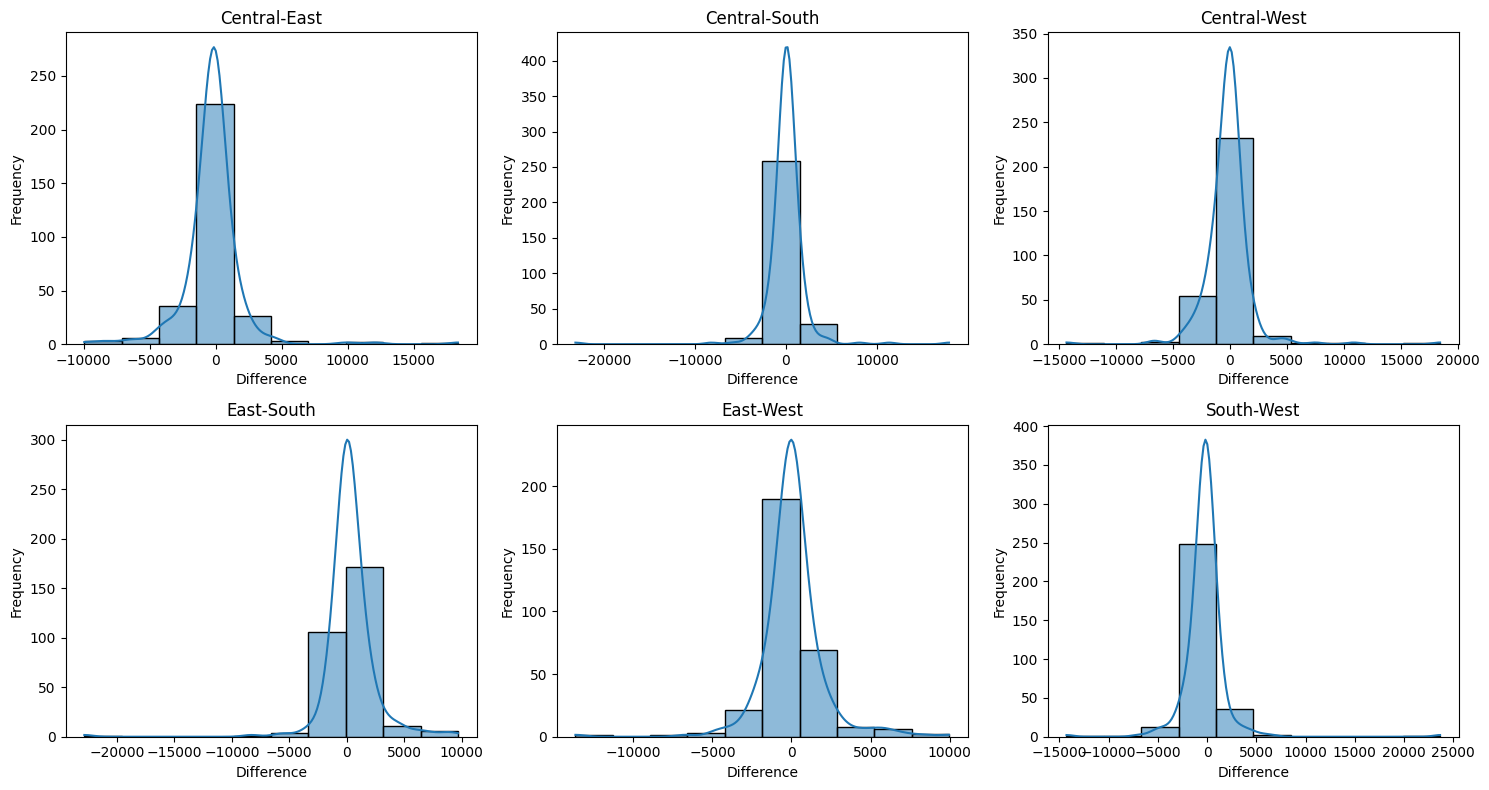

In [47]:
fig, axes = plt.subplots(
    2, 3,
    figsize=(15, 8)
)

for ax, column in zip(axes.flatten(), differences.columns):

    sns.histplot(data=differences[column], bins=10,kde=True,ax=ax)

    ax.set_title(column)
    ax.set_xlabel('Difference')
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [48]:
pg.normality(differences)

,W,pval,normal
Central-East,0.734213,1.230695e-21,False
Central-South,0.585618,3.278159e-26,False
Central-West,0.700787,8.234864e-23,False
East-South,0.702665,9.525766e-23,False
East-West,0.827301,1.214545e-17,False
South-West,0.641372,1.136187e-24,False


**Sphericity Check**

In [49]:
pg.sphericity(data=all_4_region,dv='Sales',within='Region',subject='Customer_ID')

SpherResults(spher=False, W=np.float64(0.9619713649699208), chi2=np.float64(11.5816382662971), dof=5, pval=np.float64(0.040993489670699636))

**Repeated Measures Anova**

In [50]:
rm_anova= pg.rm_anova(data=all_4_region,dv='Sales',within='Region',subject='Customer_ID',detailed=True)
rm_anova

,Source,SS,DF,MS,F,p_unc,p_GG_corr,ng2,eps,sphericity,W_spher,p_spher
0,Region,1.901345e+07,3,6.337817e+06,2.645433,0.047997,0.049386,0.006657,0.976365,False,0.961971,0.040993
1,Error,2.156182e+09,900,2.395757e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Post-hoc Comparisons**

In [51]:
pairwise = pg.pairwise_tests(
    data=all_4_region,
    dv='Sales',
    within='Region',
    subject='Customer_ID',
    padjust='holm',
    effsize='cohen'
)

pairwise

,Contrast,A,B,Paired,Parametric,T,dof,alternative,p_unc,p_corr,p_adjust,BF10,cohen
0,Region,Central,East,True,True,-1.974986,300.0,two-sided,0.049186,0.245932,holm,0.44,-0.163753
1,Region,Central,South,True,True,0.430756,300.0,two-sided,0.666955,0.923372,holm,0.071,0.034968
2,Region,Central,West,True,True,-1.407043,300.0,two-sided,0.160450,0.481350,holm,0.172,-0.116097
3,Region,East,South,True,True,2.331179,300.0,two-sided,0.020406,0.122437,holm,0.931,0.194100
4,Region,East,West,True,True,0.737021,300.0,two-sided,0.461686,0.923372,holm,0.085,0.058187
5,Region,South,West,True,True,-1.798566,300.0,two-sided,0.073093,0.292370,holm,0.318,-0.149444


### Transforming the data
##### The sales values are highly right-skewed. The log transformation:
##### log(Sales) reduces the influence of extremely large sales values and makes the distribution more suitable for parametric analysis.

**Sample Preparation and EDA**

In [52]:
all_4_region_log = all_4_region.copy()

In [53]:
all_4_region_log['log_sales']=np.log(all_4_region_log['Sales'])

In [54]:
all_4_region_log.head()

,Customer_ID,Region,Sales,log_sales
0,AA-10375,Central,178.370,5.183860
1,AA-10375,East,206.732,5.331423
2,AA-10375,South,598.480,6.394393
3,AA-10375,West,72.808,4.287826
4,AA-10645,Central,1971.460,7.586530


In [59]:
all_4_region_log.groupby('Region')['log_sales'].describe()

,count,mean,std,min,25%,50%,75%,max
Region,,,,,,,,
Central,301.0,5.732185,1.648175,-0.586987,4.715369,6.012301,6.907735,9.822122
East,301.0,6.053920,1.599407,1.195134,5.091908,6.287145,7.250171,9.212567
South,301.0,5.592482,1.636610,0.154436,4.476655,5.729515,6.761489,10.071930
West,301.0,6.125751,1.476632,0.799307,5.295243,6.386266,7.179570,9.571176


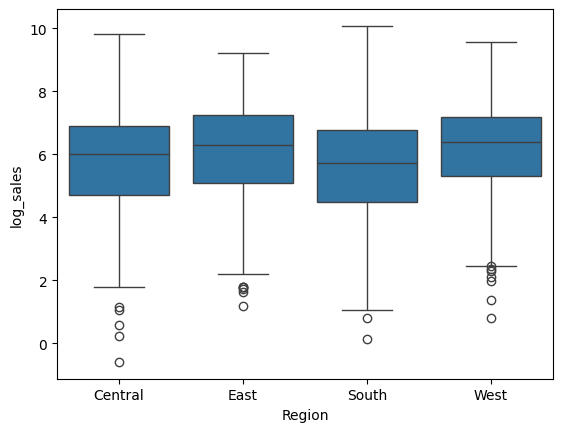

In [60]:
sns.boxplot(data=all_4_region_log,x='Region',y='log_sales')
plt.show()

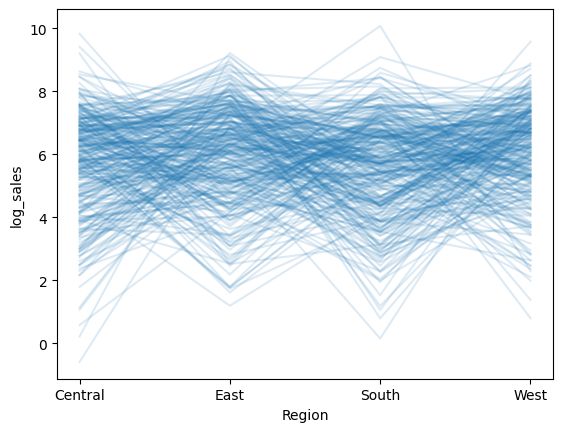

In [61]:
sns.lineplot(data=all_4_region_log,x='Region',units='Customer_ID',y='log_sales',estimator=None, alpha=0.15)
plt.show()

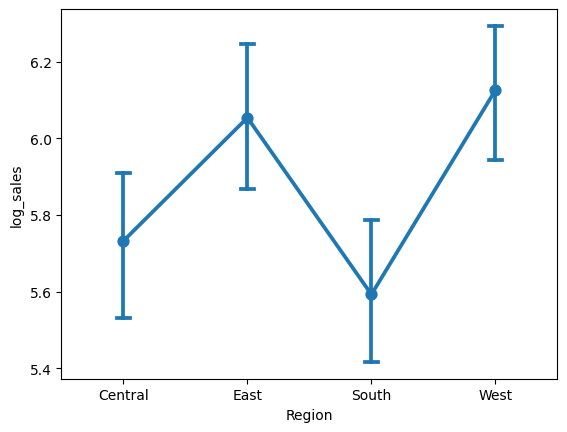

In [62]:
sns.pointplot(
    data=all_4_region_log,
    x='Region',
    y='log_sales',
    errorbar='ci',
    capsize=0.1
)

plt.show()

In [63]:
wide= all_4_region_log.pivot(index='Customer_ID',columns='Region',values='log_sales')
wide

Region,Central,East,South,West
Customer_ID,,,,
AA-10375,5.183860,5.331423,6.394393,4.287826
AA-10645,7.586530,7.268453,5.675863,7.236631
AB-10060,5.481264,8.409018,5.811740,7.898752
AB-10105,9.407681,4.770346,6.737963,7.193067
AB-10165,3.618886,4.773393,5.099622,6.677413
...,...,...,...,...
VM-21835,2.789937,5.178069,4.067316,4.857251
VP-21760,6.452245,6.596130,7.546333,4.608764
VW-21775,7.108629,8.222960,3.061520,7.060215


In [64]:
diff = pd.DataFrame({
     "Central-East": wide["Central"] - wide["East"],
    "Central-South": wide["Central"] - wide["South"],
    "Central-West": wide["Central"] - wide["West"],
    "East-South": wide["East"] - wide["South"],
    "East-West": wide["East"] - wide["West"],
    "South-West": wide["South"] - wide["West"]
})

In [65]:
diff.head()

,Central-East,Central-South,Central-West,East-South,East-West,South-West
Customer_ID,,,,,,
AA-10375,-0.147563,-1.210533,0.896034,-1.062970,1.043597,2.106567
AA-10645,0.318077,1.910667,0.349899,1.592590,0.031822,-1.560768
AB-10060,-2.927754,-0.330476,-2.417488,2.597278,0.510266,-2.087012
AB-10105,4.637336,2.669718,2.214614,-1.967617,-2.422722,-0.455104
AB-10165,-1.154507,-1.480736,-3.058527,-0.326230,-1.904021,-1.577791


#### Assumptions Checking

**Normality Checks**

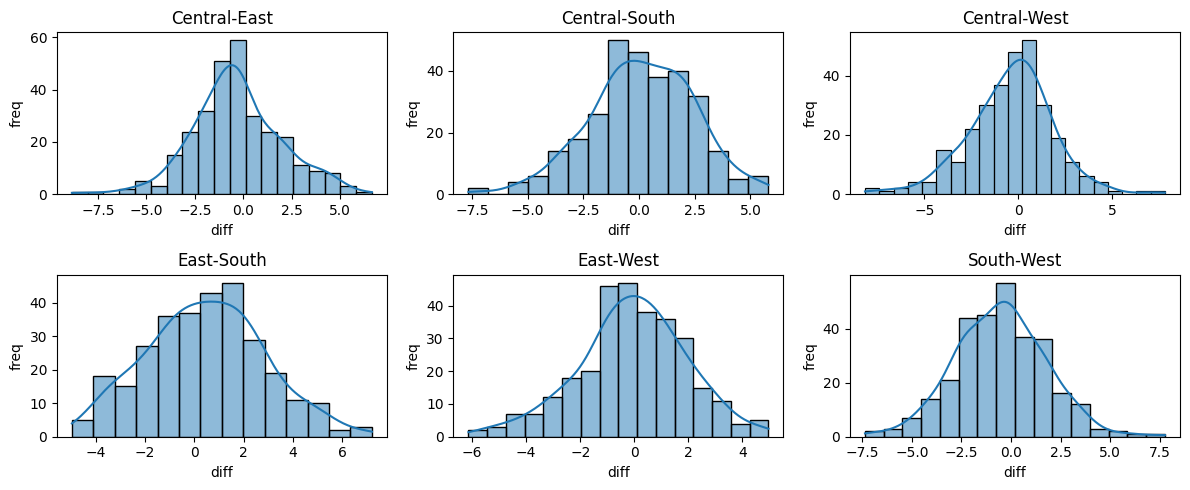

In [66]:
figs,axs= plt.subplots(2,3,
                figsize=(12,5))
for ax,column in zip(axs.flatten(),diff.columns):
    sns.histplot(data=diff[column],kde=True,ax=ax)
    ax.set_title(column)
    ax.set_xlabel('diff')
    ax.set_ylabel('freq')
plt.tight_layout()
plt.show()

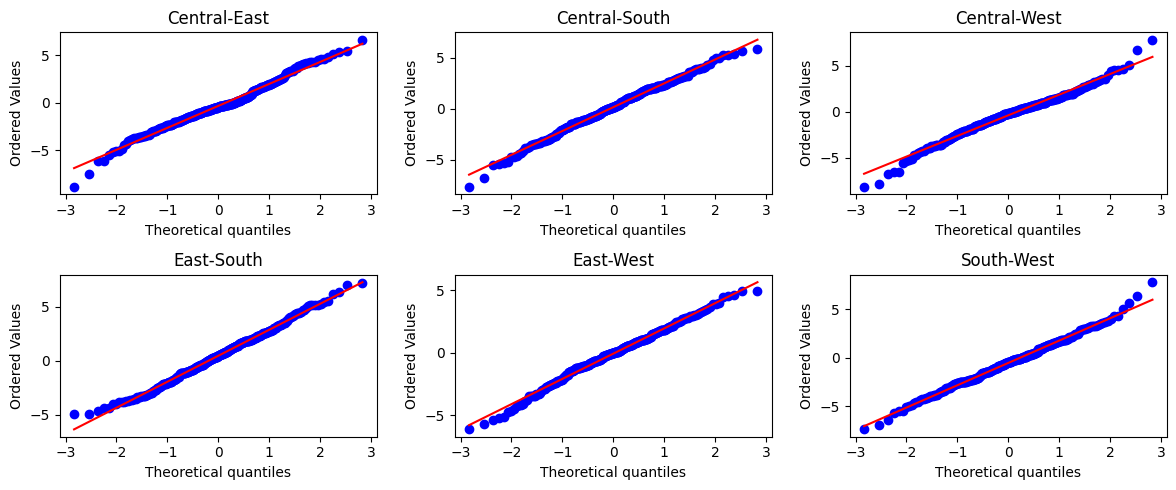

In [67]:
figs,axs= plt.subplots(2,3,
                figsize=(12,5))
for ax,column in zip(axs.flatten(),diff.columns):
    stats.probplot(diff[column],dist='norm',plot=ax)
    ax.set_title(column)
plt.tight_layout()
plt.show()

In [68]:
pg.normality(diff)

,W,pval,normal
Central-East,0.986802,0.007466,False
Central-South,0.994508,0.353560,True
Central-West,0.984030,0.001978,False
East-South,0.994339,0.327574,True
East-West,0.993047,0.176331,True
South-West,0.995884,0.618487,True


**Sphericity Check**

In [69]:
sphericity= pg.sphericity(data=all_4_region_log,dv='log_sales',within='Region',subject='Customer_ID')
sphericity

SpherResults(spher=False, W=np.float64(0.9575488466523752), chi2=np.float64(12.95813519427116), dof=5, pval=np.float64(0.023775003443423922))

**Repeated Measures ANOVA**

In [70]:
anova_rm= pg.rm_anova(data=all_4_region_log,dv='log_sales',within='Region',subject='Customer_ID',detailed=True)
anova_rm

,Source,SS,DF,MS,F,p_unc,p_GG_corr,ng2,eps,sphericity,W_spher,p_spher
0,Region,58.723983,3,19.574661,7.615041,0.00005,0.00006,0.018951,0.973432,False,0.957549,0.023775
1,Error,2313.473374,900,2.570526,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Post-hoc Comparisons**

In [71]:
pair_comparison= pg.pairwise_tests(data=all_4_region_log,
                                   dv='log_sales',
                                   within='Region',
                                   subject='Customer_ID',
                                   padjust='holm',
                                   effsize='cohen')
pair_comparison

,Contrast,A,B,Paired,Parametric,T,dof,alternative,p_unc,p_corr,p_adjust,BF10,cohen
0,Region,Central,East,True,True,-2.408606,300.0,two-sided,0.016616,0.049849,holm,1.113,-0.198116
1,Region,Central,South,True,True,1.043747,300.0,two-sided,0.297443,0.594885,holm,0.111,0.085060
2,Region,Central,West,True,True,-3.034487,300.0,two-sided,0.002620,0.010482,holm,5.772,-0.251519
3,Region,East,South,True,True,3.345351,300.0,two-sided,0.000926,0.004631,holm,14.926,0.285170
4,Region,East,West,True,True,-0.618425,300.0,two-sided,0.536764,0.594885,holm,0.078,-0.046667
5,Region,South,West,True,True,-4.044695,300.0,two-sided,0.000067,0.000400,holm,172.662,-0.342130


#### Permutation Test for Repeated Measures ANOVA

In [256]:
observed_f= rm_anova['F'][0]
observed_f

np.float64(2.645433326982589)

In [259]:
rnge= np.random.default_rng(42)
permuted_f= []
for _ in range(10_000):

    df_permuted = all_4_region.copy()

    for customer in df_permuted['Customer_ID'].unique():

        mask = (
            df_permuted['Customer_ID'] == customer
        )

        df_permuted.loc[mask, 'Sales'] = (
            rnge.permutation(
                df_permuted.loc[
                    mask,
                    'Sales'
                ].to_numpy()
            )
        )

    result = pg.rm_anova(
        data=df_permuted,dv='Sales',within='Region',subject='Customer_ID',detailed=True)
    f = result['F'][0]

    permuted_f.append(f)

permuted_f = np.array(permuted_f)

In [260]:
p_value = np.mean(
    permuted_f >= observed_f
)

p_value

np.float64(0.0451)

**Results**

Among the 301 customers who purchased in all four regions, the repeated-measures ANOVA on log-transformed sales indicated a statistically significant regional effect after applying the Greenhouse-Geisser correction, (F=7.615), (p_{GG}=0.00006), with generalized eta-squared of (eta_G^2=.019). Holm-adjusted post-hoc comparisons identified significant differences between Central and East, Central and West, East and South, and South and West, while Central versus South and East versus West were not statistically significant.

A within-customer permutation analysis produced (p=.0451), which also fell below the 5% significance level. Although this supported the rejection of the null hypothesis, the permutation result provided weaker evidence than the Greenhouse-Geisser-corrected parametric ANOVA.

Overall, the results indicate that the evidence for regional differences depends on the customer groups being examined: no statistically significant East-West difference was detected among the 32 customers purchasing in those two regions, whereas evidence of differences across the four regions was observed among the 301 customers purchasing in all four regions.

In [56]:
import pandas as pd

results = pd.DataFrame({
    "Analysis": [
        "East vs West",
        "East vs West",
        "East vs West",
        "East vs West",
        "Four-Region Repeated Measures ANOVA",
        "Four-Region Repeated Measures ANOVA"
    ],
    "Method": [
        "Paired t-test",
        "Wilcoxon signed-rank test",
        "Sign-flip permutation test",
        "Cohen's d",
        "Greenhouse-Geisser corrected RM-ANOVA",
        "Within-customer permutation test"
    ],
    "Statistic": [
        -0.1112,
        252,
        None,
        -0.0196,
        7.615,
        None
    ],
    "P_Value": [
        0.9122,
        0.8320,
        0.9123,
        None,
        0.00006,
        0.0451
    ],
    "Sample_Size": [
        32,
        32,
        32,
        32,
        301,
        301
    ]
})

results

,Analysis,Method,Statistic,P_Value,Sample_Size
0,East vs West,Paired t-test,-0.1112,0.91220,32
1,East vs West,Wilcoxon signed-rank test,252.0000,0.83200,32
2,East vs West,Sign-flip permutation test,NaN,0.91230,32
3,East vs West,Cohen's d,-0.0196,NaN,32
4,Four-Region Repeated Measures ANOVA,Greenhouse-Geisser corrected RM-ANOVA,7.6150,0.00006,301
5,Four-Region Repeated Measures ANOVA,Within-customer permutation test,NaN,0.04510,301


In [59]:
import os

os.getcwd()

'C:\\Users\\Israel Shitttu'

In [60]:
os.listdir()

['.config',
 '.copilot',
 '.docker',
 '.gitconfig',
 '.ipynb_checkpoints',
 '.ipython',
 '.jupyter',
 '.matplotlib',
 '.vscode',
 '.vscode-shared',
 'AppData',
 'Application Data',
 'Contacts',
 'Cookies',
 'Customer segmentation.ipynb',
 'Desktop',
 'Documents',
 'Downloads',
 'Favorites',
 'Hypothesis_Testing.ipynb',
 'IntelGraphicsProfiles',
 'Links',
 'Local Settings',
 'Music',
 'My Documents',
 'NetHood',
 'NTUSER.DAT',
 'ntuser.dat.LOG1',
 'ntuser.dat.LOG2',
 'NTUSER.DAT{a2332f18-cdbf-11ec-8680-002248483d79}.TM.blf',
 'NTUSER.DAT{a2332f18-cdbf-11ec-8680-002248483d79}.TMContainer00000000000000000001.regtrans-ms',
 'NTUSER.DAT{a2332f18-cdbf-11ec-8680-002248483d79}.TMContainer00000000000000000002.regtrans-ms',
 'ntuser.ini',
 'OneDrive',
 'OneDrive - elparahconsult.com',
 'OneDrive - elparahconsult.com (1)',
 'one_way_anova.ipynb',
 'Pictures',
 'PrintHood',
 'Recent',
 'Saved Games',
 'Searches',
 'SendTo',
 'Start Menu',
 'Templates',
 'Untitled.ipynb',
 'Untitled1.ipynb',
 'Vide

In [61]:
results.to_csv(
    r"C:\Data Analyst Portfolio\Python\Statistical Hypothesis Testing\Results\statistical_results.csv",
    index=False
)

In [62]:
posthoc_results = pd.DataFrame({
    "Comparison": [
        "Central vs East",
        "Central vs South",
        "Central vs West",
        "East vs South",
        "East vs West",
        "South vs West"
    ],
    "Adjusted_P_Value": [
        0.049849,
        0.594885,
        0.010482,
        0.004631,
        0.594885,
        0.000400
    ],
    "Cohens_d": [
        -0.198,
        0.085,
        -0.252,
        0.285,
        -0.047,
        -0.342
    ]
})

posthoc_results

,Comparison,Adjusted_P_Value,Cohens_d
0,Central vs East,0.049849,-0.198
1,Central vs South,0.594885,0.085
2,Central vs West,0.010482,-0.252
3,East vs South,0.004631,0.285
4,East vs West,0.594885,-0.047
5,South vs West,0.000400,-0.342


In [63]:
posthoc_results.to_csv(
    r"C:\Data Analyst Portfolio\Python\Statistical Hypothesis Testing\Results\post-hoc_comparisons.csv",
    index=False
)